In [2]:
import pandas as pd
import numpy as np

In [3]:
model=pd.read_csv(r'posterior_samples.csv')
model.head()

,w[1],w[2],w[3],w[4],w[5],w[6],w[7],w[8],w[9],w[10],...,w[43],w[44],w[45],w[46],w[47],w[48],w[49],w[50],b,lp__
0,-3.419474,0.734203,-1.557125,-1.123663,-1.282204,0.408819,-0.355089,-1.479366,-0.471051,-0.455143,...,-0.312281,-0.381158,1.031733,-0.675700,-2.237514,-0.712418,1.558005,-1.501552,-1.247707,-31.833778
1,-2.064754,-0.062514,-0.199971,-0.588217,-0.408806,-0.044690,0.343838,0.585738,-0.555024,-0.544040,...,1.233835,-0.032497,0.094455,-0.273259,0.774553,0.537422,-0.051460,1.220576,0.094639,-13.297790
2,-2.900860,0.345925,-0.805947,0.191398,-1.480680,-0.662834,0.758224,-0.961148,0.629402,0.244386,...,-0.316280,-0.915640,0.346558,-0.330921,0.068165,0.974129,-1.432154,0.250555,-0.218114,-20.449972
3,-2.530113,-0.539611,-0.763853,-0.961690,-0.836358,-0.847514,0.364688,0.857566,0.332693,0.735803,...,0.676545,-1.353308,-0.784896,-0.123209,-0.325998,0.442209,0.148629,-0.392166,0.091821,-19.041322
4,-2.831578,0.312440,-0.611838,0.259734,-0.238478,-0.508827,0.417216,0.590017,0.841549,-0.663777,...,0.155710,-1.315840,-0.039050,0.017416,-0.730668,0.222920,0.442248,0.332305,-0.868304,-22.772980


In [4]:
W=model.iloc[:,0:50].values
B=model.iloc[:,50].values

Making predictions


In [5]:
X=pd.read_csv(r'X.csv')
y=pd.read_csv(r'Y.csv')

In [6]:
X=X.iloc[:,1:].values

In [7]:
y=y.iloc[:,1:].values
y=y.flatten()

In [8]:
X.shape

(100, 50)

In [9]:
probs = []
for i in range(W.shape[0]):
    w = W[i]        
    b = B[i]
    logits = X @ w + b   
    probs.append(1 / (1 + np.exp(-logits)))

probs = np.array(probs)  

In [10]:
mean_probs = probs.mean(axis=0)
y_pred = (mean_probs > 0.5).astype(int)   

In [11]:
y_pred.shape

(100,)

In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(y, y_pred)

1.0

C:\Users\Rahul Hegde\AppData\Local\Temp\ipykernel_6304\1057856022.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


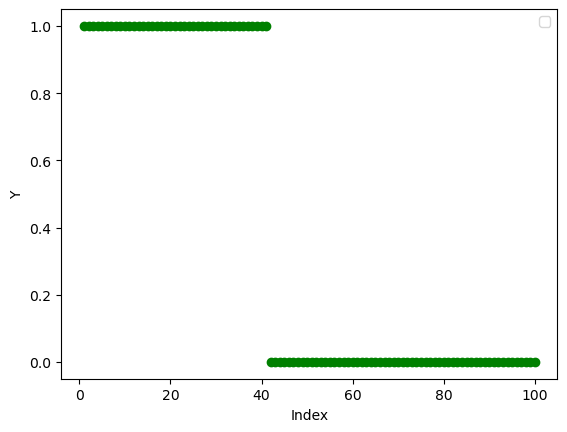

In [13]:
import matplotlib.pyplot as plt
x = np.arange(1, 101)
plt.scatter(x,y,color='g')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Y')
plt.show()

For curiousity, Let us build a Logistic Regression model using default sklearn logistic regression for binary classification

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X, y)

LogisticRegression(max_iter=2000)

In [15]:
sk_probs = model.predict_proba(X)[:,1]
sk_preds = (sk_probs > 0.5).astype(int)

C:\Users\Rahul Hegde\AppData\Local\Temp\ipykernel_6304\387538986.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


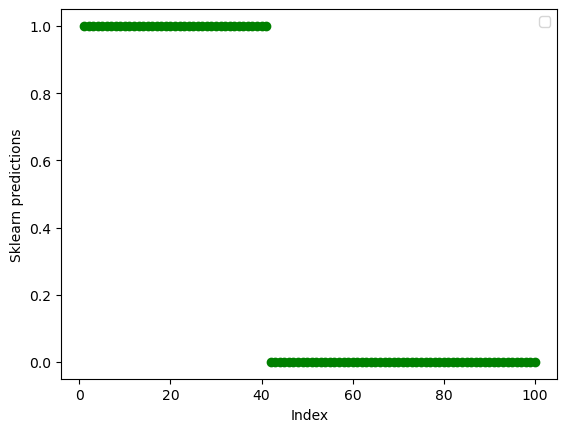

In [ ]:
plt.scatter(x,sk_preds,color='g')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Sklearn predictions')
plt.show()

In [18]:
accuracy_score(y, sk_preds)

1.0

Clearly, as the number of samples was quite small, both the approaches gave the same answer. Now, to make things harder for the MCMC chain, PCA reduction will be done to 100 parameters/features. 

In [4]:
model1=pd.read_csv(r'posterior_samples_1.csv')

In [5]:
model1.head()

,w[1],w[2],w[3],w[4],w[5],w[6],w[7],w[8],w[9],w[10],...,w[93],w[94],w[95],w[96],w[97],w[98],w[99],w[100],b,lp__
0,-4.464817,1.847498,-1.357050,0.474405,-1.302716,-0.628014,1.106059,0.276809,0.219588,0.703786,...,0.151831,0.311898,-2.192480,0.945688,0.132643,-0.307757,1.152537,1.372463,1.119081,-64.068043
1,-3.462366,0.629979,-0.646137,0.441214,-0.861214,-0.844365,0.516530,-0.104399,-1.099870,-0.483938,...,-0.445079,-0.331261,1.779230,-0.431465,0.071736,0.166548,-0.593925,-1.364827,-1.700225,-53.068953
2,-3.311809,1.803105,-0.763802,-1.900725,0.204576,0.132669,-1.593513,-0.219704,1.092023,1.219121,...,0.033183,0.466491,-1.807815,0.353230,-0.185133,-0.120587,0.563479,1.298315,1.281188,-45.250187
3,-3.493116,1.650325,-0.795184,-1.234413,-0.540134,1.027871,-0.713070,0.467272,0.833103,-0.275799,...,0.315151,1.096900,-0.568798,-0.238701,-1.321802,0.610319,-0.388341,1.444524,0.720963,-47.792869
4,-3.067291,0.927103,-1.217445,0.350183,-0.903339,-0.330315,-0.216789,0.381368,-1.398915,1.107252,...,-0.690080,-1.221868,0.769296,0.021652,0.837155,-0.528383,0.477351,-0.890583,-1.087923,-42.863852


In [7]:
W1=model1.iloc[:,0:100].values
B1=model1.iloc[:,100].values

In [8]:
X1=pd.read_csv(r'X1.csv')
y=pd.read_csv(r'Y.csv')
X1=X1.iloc[:,1:].values
y=y.iloc[:,1:].values
y=y.flatten()


In [10]:
probs1 = []
for i in range(W1.shape[0]):
    w = W1[i]        
    b = B1[i]
    logits = X1 @ w + b   
    probs1.append(1 / (1 + np.exp(-logits)))

probs1 = np.array(probs1) 

In [11]:
mean_probs = probs1.mean(axis=0)
y_pred1 = (mean_probs > 0.5).astype(int)

In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(y, y_pred1)

1.0

C:\Users\Rahul Hegde\AppData\Local\Temp\ipykernel_11348\1057856022.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


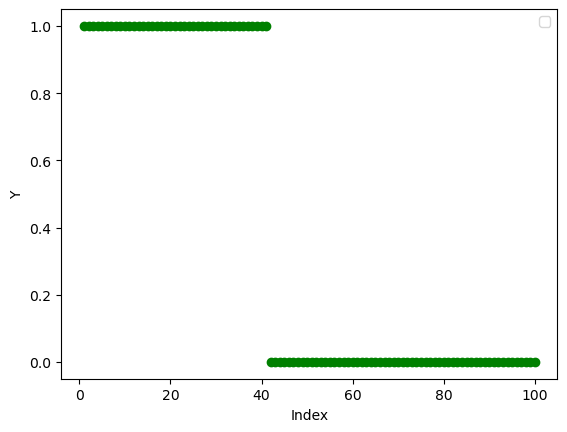

In [14]:
import matplotlib.pyplot as plt
x = np.arange(1, 101)
plt.scatter(x,y,color='g')
plt.legend()
plt.xlabel('Index')
plt.ylabel('Y')
plt.show()